<a href="https://colab.research.google.com/github/chhavi-29/Speech-Emotion-Recognizer-Project-/blob/main/NOTEBOOK_1_Feature_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## CELL 1 — Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# This folder will store all your project files permanently
SAVE_DIR = '/content/drive/MyDrive/SER_Project'
os.makedirs(SAVE_DIR, exist_ok=True)

print('✅ Google Drive mounted!')
print(f'✅ Save folder: {SAVE_DIR}')

Mounted at /content/drive
✅ Google Drive mounted!
✅ Save folder: /content/drive/MyDrive/SER_Project


---
## CELL 2 — Install Libraries

In [ ]:
!pip install librosa kagglehub -q
print('✅ Libraries installed!')

✅ Libraries installed!


---
## CELL 3 — Import Everything

In [ ]:
import os
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import warnings
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')

# ── Make sure SAVE_DIR is set ──
SAVE_DIR = '/content/drive/MyDrive/SER_Project'

print('✅ All imports successful!')

✅ All imports successful!


---
## CELL 4 — Check GPU

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'✅ GPU is ON: {gpus[0].name}')
else:
    print('❌ NO GPU FOUND!')
    print('   → Go to Runtime → Change runtime type → T4 GPU → Save')
    print('   → Then Runtime → Disconnect and delete runtime')
    print('   → Then re-run from Cell 1')

✅ GPU is ON: /physical_device:GPU:0


---
## CELL 5 — Download RAVDESS Dataset

In [ ]:
import kagglehub

DATASET_PATH = kagglehub.dataset_download('uwrfkaggler/ravdess-emotional-speech-audio')

print(f'✅ Dataset downloaded to: {DATASET_PATH}')

# Count how many .wav files exist
wav_count = sum(
    1 for root, _, files in os.walk(DATASET_PATH)
    for f in files if f.endswith('.wav')
)
print(f'✅ Total .wav files found: {wav_count}')

Using Colab cache for faster access to the 'ravdess-emotional-speech-audio' dataset.
✅ Dataset downloaded to: /kaggle/input/ravdess-emotional-speech-audio
✅ Total .wav files found: 2880


---
## CELL 6 — Define Emotion Labels

In [ ]:
# RAVDESS filename format: 03-01-06-01-02-01-12.wav
# The 3rd number (index 2) is the emotion code

EMOTION_MAP = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}

LABEL_TO_INT = {emotion: idx for idx, emotion in enumerate(EMOTION_MAP.values())}
INT_TO_LABEL = {idx: emotion for emotion, idx in LABEL_TO_INT.items()}

print('✅ Emotion labels defined:')
for k, v in LABEL_TO_INT.items():
    print(f'   {v} → {k}')

✅ Emotion labels defined:
   0 → neutral
   1 → calm
   2 → happy
   3 → sad
   4 → angry
   5 → fearful
   6 → disgust
   7 → surprised


---
## CELL 7 — Define Augmentation Functions

In [ ]:
# These functions create slightly modified copies of each audio file

def add_noise(y):
    """Add small random noise to audio"""
    return y + 0.005 * np.random.randn(len(y))

def time_shift(y):
    """Shift audio slightly forward or backward in time"""
    shift = int(np.random.uniform(-0.2, 0.2) * len(y))
    return np.roll(y, shift)

def pitch_shift(y, sr):
    """Raise pitch by 2 semitones"""
    return librosa.effects.pitch_shift(y, sr=sr, n_steps=2)

def time_stretch(y):
    """Slow audio down slightly"""
    return librosa.effects.time_stretch(y, rate=0.9)

print('✅ Augmentation functions ready!')

✅ Augmentation functions ready!


---
## CELL 8 — Define Feature Extraction Function


In [ ]:
def extract_features(y, sr):
    """
    Extract audio features from one audio clip.

    Feature breakdown (total = 174):
      MFCC           → 40
      MFCC Delta     → 40
      MFCC Delta2    → 40
      Mel Spectrogram→ 40
      Chroma         → 12
      ZCR            →  1
      RMS Energy     →  1
      ─────────────────────
      TOTAL          → 174

    Returns shape: (128, 174)  → (timesteps, features)
    """
    # Remove silence from start and end
    y, _ = librosa.effects.trim(y, top_db=20)

    # Extract each feature
    mfcc         = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)                          # shape: (40, T)
    mfcc_delta   = librosa.feature.delta(mfcc)                                           # shape: (40, T)
    mfcc_delta2  = librosa.feature.delta(mfcc, order=2)                                  # shape: (40, T)
    mel          = librosa.power_to_db(
                       librosa.feature.melspectrogram(y=y, sr=sr, n_mels=40),
                       ref=np.max)                                                        # shape: (40, T)
    chroma       = librosa.feature.chroma_stft(y=y, sr=sr, n_chroma=12)                 # shape: (12, T)
    zcr          = librosa.feature.zero_crossing_rate(y)                                 # shape: ( 1, T)
    rms          = librosa.feature.rms(y=y)                                              # shape: ( 1, T)

    # Stack all features vertically → shape: (174, T)
    all_features = np.concatenate(
        [mfcc, mfcc_delta, mfcc_delta2, mel, chroma, zcr, rms],
        axis=0
    )

    # Pad or trim to exactly 128 timesteps
    MAX_LEN = 128
    if all_features.shape[1] < MAX_LEN:
        # Pad with zeros on the right
        pad = MAX_LEN - all_features.shape[1]
        all_features = np.pad(all_features, ((0, 0), (0, pad)), mode='constant')
    else:
        # Trim from the right
        all_features = all_features[:, :MAX_LEN]

    # Transpose → shape: (128, 174)
    return all_features.T



test_y, test_sr = librosa.load(librosa.ex('trumpet'), sr=22050, duration=3.0)
test_feat = extract_features(test_y, test_sr)

print(f'✅ Feature shape: {test_feat.shape}')

if test_feat.shape == (128, 174):
    print('✅ Shape is correct! (128 timesteps, 174 features)')
else:
    print(f'❌ ERROR: Expected (128, 174) but got {test_feat.shape}')
    print('   Do NOT continue. Check the function above.')

✅ Feature shape: (128, 174)
✅ Shape is correct! (128 timesteps, 174 features)


cell 9 — Extract Features

In [ ]:
X_list = []       # will hold feature arrays
y_list = []       # will hold emotion labels
errors = 0

# Collect all .wav file paths
all_wav_files = []
for root, _, files in os.walk(DATASET_PATH):
    for fname in files:
        if fname.endswith('.wav'):
            all_wav_files.append(os.path.join(root, fname))

print(f'Found {len(all_wav_files)} audio files. Starting extraction...\n')

for filepath in tqdm(all_wav_files, desc='Extracting features'):
    filename = os.path.basename(filepath)
    parts    = filename.split('-')

    # Skip if filename doesn't match RAVDESS format
    if len(parts) < 3:
        continue
    emotion_code = parts[2]
    if emotion_code not in EMOTION_MAP:
        continue

    label = LABEL_TO_INT[EMOTION_MAP[emotion_code]]

    try:
        # Load audio (max 3 seconds)
        y, sr = librosa.load(filepath, sr=22050, duration=3.0)

        # ── Original sample ──
        X_list.append(extract_features(y, sr))
        y_list.append(label)

        # ── 4 Augmented copies ──
        for aug_fn in [
            lambda a: add_noise(a),
            lambda a: time_shift(a),
            lambda a: pitch_shift(a, sr),
            lambda a: time_stretch(a),
        ]:
            try:
                X_list.append(extract_features(aug_fn(y), sr))
                y_list.append(label)
            except:
                errors += 1

    except Exception as e:
        errors += 1

# Convert to numpy arrays
X = np.array(X_list, dtype=np.float32)
y = np.array(y_list, dtype=np.int32)

print(f'\n✅ Extraction complete!')
print(f'   X shape : {X.shape}    ← should be (N, 128, 174)')
print(f'   y shape : {y.shape}')
print(f'   Errors  : {errors}')

Found 2880 audio files. Starting extraction...



Extracting features: 100%|██████████| 2880/2880 [11:07<00:00,  4.32it/s]



✅ Extraction complete!
   X shape : (14400, 128, 174)    ← should be (N, 128, 174)
   y shape : (14400,)
   Errors  : 0


---
## CELL 10 — Visualize Class Distribution

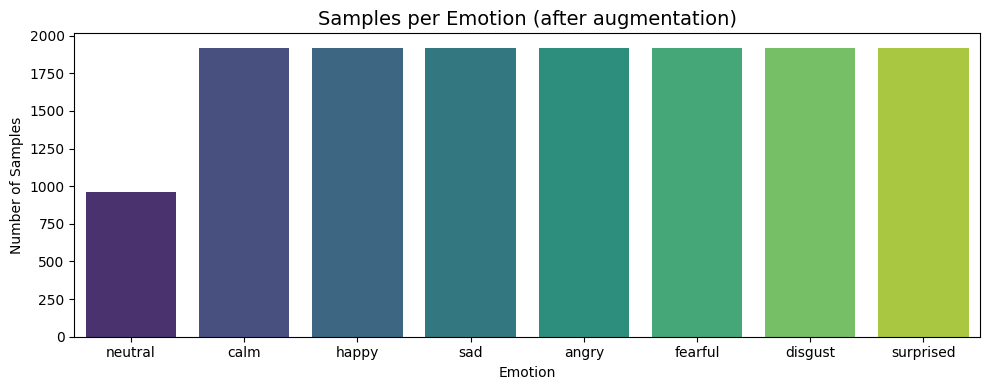

In [ ]:
plt.figure(figsize=(10, 4))
unique, counts = np.unique(y, return_counts=True)
emotion_names  = [INT_TO_LABEL[i] for i in unique]

sns.barplot(x=emotion_names, y=counts, palette='viridis')
plt.title('Samples per Emotion (after augmentation)', fontsize=14)
plt.xlabel('Emotion')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/class_distribution.png', dpi=150)
plt.show()


---
## CELL 11 — Normalize Features

In [ ]:
N, T, F = X.shape
print(f'Shape before normalization: {X.shape}')
print(f'  N = {N} samples')
print(f'  T = {T} timesteps')
print(f'  F = {F} features')

# Fit scaler on flattened data, then reshape back
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X.reshape(-1, F)).reshape(N, T, F)

print(f'\n✅ Normalization done!')
print(f'   X_scaled shape: {X_scaled.shape}')

Shape before normalization: (14400, 128, 174)
  N = 14400 samples
  T = 128 timesteps
  F = 174 features

✅ Normalization done!
   X_scaled shape: (14400, 128, 174)


---
## CELL 12 — Save Everything to Google Drive


In [ ]:
# 1. Save feature arrays
np.save(f'{SAVE_DIR}/X_features.npy', X_scaled)
np.save(f'{SAVE_DIR}/y_labels.npy',   y)

# 2. Save the scaler (needed for inference later)
with open(f'{SAVE_DIR}/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# 3. Save label map
with open(f'{SAVE_DIR}/label_map.json', 'w') as f:
    json.dump({
        'label_to_int': LABEL_TO_INT,
        'int_to_label': INT_TO_LABEL
    }, f, indent=2)

# 4. Save metadata (shape info — prevents future mismatch errors!)
with open(f'{SAVE_DIR}/meta.json', 'w') as f:
    json.dump({
        'n_samples'  : int(N),
        'timesteps'  : int(T),
        'n_features' : int(F),
        'shape'      : [int(N), int(T), int(F)]
    }, f, indent=2)
